# 2 часть

 модели линейной регрессии и логистической регрессии с лучшими гиперпараметрами

1. Обучить  линейные модели для регрессионной целевой переменной __price: линейная регрессия, Lasso, Ridge
    - Найти оптимальный коэффициент регуляризации для каждой модели (подготовьте более 10+ экспериментов для каждой модели)
    - Посчитать оценки (scores) для каждого эксперимента
2. Обучите  модели логистической регрессии для целевой переменной __churn: логистическая регрессия без регуляризации, логистическая регрессия + L1, логистическая регрессия + L2
    - Найдите оптимальный коэффициент регуляризации для каждой модели (подготовьте более 10+ экспериментов для каждой модели)
    - Посчитать оценки (scores) для каждого эксперимента 
3. Выбрать лучшую регрессионную и классификационную модель на основе результатов в таблицах scoring_price и scoring_churn
4. Подготовить предсказания на основе лучших моделей; результаты должны быть сохранены в следующих столбцах:
    - Для регрессионной модели сохранить в столбец __price_predict
    - Для классификационной модели сохранить ВЕРОЯТНОСТЬ в столбец __churn_prob
   



# Ваши метрики из экспериментов

Одна строка — один эксперимент

In [ ]:
import numpy as np
import pandas as pd

# table with metrics for Regression models
scoring_price = pd.DataFrame([
    # 
    # ('Lasso', 0.1, 'mean_squared_log_error', 0.2101, 0.1661),
    # ...
    # fill table with results from your experiments
], columns=['model', 'alpha', 'metric_name', 'score_train', 'score_valid'])

scoring_price

,model,alpha,metric_name,score_train,score_valid


In [2]:
scoring_churn = pd.DataFrame([
    # ...
    # fill table with results from your experiments
], columns=['model', 'C', 'metric_name', 'score_train', 'score_valid'])

scoring_churn

,model,C,metric_name,score_train,score_valid


## Метрики для оценки качества модели

In [3]:
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import roc_auc_score

# this metric bigger is better for price and churn target
def metric_for_price(y_true, y_pred):
    """ mean_squared_log_error. bigger is better """
    return round(-mean_squared_log_error(y_true=y_true, y_pred=y_pred), 3)


def metric_for_churn(y_true, y_score):
    """ roc_auc_score. bigger is better """
    return round(roc_auc_score(y_true=y_true, y_score=y_score), 3)

# ЗДЕСЬ НАЧИНАЕТСЯ ВАША РАБОТА

In [7]:
import pandas as pd

NAME = "Kirill_Viksman"

dataset = pd.read_csv(f"1_{NAME}.csv", index_col=0)
SHAPE = dataset.shape

train_all = dataset[dataset["dtype"] == "train"].copy()
test = dataset[dataset["dtype"] == "test"].copy()

print("SHAPE:", SHAPE)
print("train_all:", train_all.shape)
print("test:", test.shape)

SHAPE: (30471, 399)
train_all: (20483, 399)
test: (9988, 399)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_log_error, roc_auc_score


In [9]:
import os
import pandas as pd

NAME = "Kirill_Viksman"

candidate_paths = [
    f"1_{NAME}.csv",
    f"0_{NAME}.csv",
    "0_Kirill_Viksman.csv",
    "1_Kirill_Viksman.csv",
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Не найден CSV. Загрузите файл через files.upload() "
        "и убедитесь, что имя файла совпадает с 0_NAME.csv или 1_NAME.csv."
    )

dataset = pd.read_csv(data_path, index_col=0)

print("data_path:", data_path)
print("SHAPE:", dataset.shape)
dataset.head()


data_path: 1_Kirill_Viksman.csv
SHAPE: (30471, 399)


,dtype,max_floor,state,marital_status,big_market_raion,total_revolving_bal,market_count_1500,leisure_count_3000,total_ct_chng_q4_q1,water_1line,...,f_int_weekend_x_trans_ct_m,f_int_month_sin_x_trans_amt_m,f_int_month_cos_x_trans_amt_m,f_int_log1p_amen,f_int_log1p_access_total,f_int_log1p_risk,f_int_risk_sq,f_int_access_score_sq,f_int_amen_sq,f_int_attractiveness_index
0,train,5.0,2.0,Married,no,866,0,3,0.783,no,...,0.0,-5.844827e+01,-1.073677e-14,3.295837,2.943768,0.000000,0.0,1.102777,676.0,3.748182
1,train,17.0,2.0,Single,no,7,2,0,0.642,no,...,0.0,1.859444e+02,1.138581e-14,3.367296,2.954079,0.000000,0.0,0.946603,784.0,4.529519
2,train,NaN,NaN,Married,no,0,0,0,0.608,no,...,0.0,-1.035507e-14,4.227777e+01,0.000000,4.385213,0.000000,0.0,0.041669,0.0,1.008262
3,train,1.0,1.0,Single,no,1370,0,0,0.500,no,...,0.0,-7.836523e+01,4.524419e+01,0.000000,3.214322,1.098612,4.0,0.483510,0.0,0.972363
4,train,9.0,2.0,Married,no,1382,3,4,0.563,no,...,0.0,1.002347e-14,-8.184782e+01,4.077538,3.017660,1.609438,16.0,0.488132,3364.0,1.504772


In [38]:
required_cols = {"dtype", "__price", "__churn"}
missing_required = sorted(list(required_cols - set(dataset.columns)))
if missing_required:
    raise ValueError(f"Отсутствуют нужные столбцы: {missing_required}")

print("dtype value counts:")
print(dataset["dtype"].value_counts(dropna=False))

# Разделяем по dtype
train_all = dataset[dataset["dtype"] == "train"].copy()
test_public = dataset[dataset["dtype"] == "test"].copy()

# Проверяем, что разметка есть на train
if train_all["__price"].isna().any() or train_all["__churn"].isna().any():
    raise ValueError("В train-части есть пропуски в __price или __churn")

print("train_all shape:", train_all.shape)
print("test_public shape:", test_public.shape)

# Проверяем бинарность churn
print("Unique __churn:", sorted(train_all["__churn"].unique()))


dtype value counts:
dtype
train    20483
test      9988
Name: count, dtype: int64
train_all shape: (20483, 404)
test_public shape: (9988, 404)
Unique __churn: [np.float64(0.0), np.float64(1.0)]


<class 'pandas.core.frame.DataFrame'>
Index: 30471 entries, 0 to 9987
Columns: 399 entries, dtype to f_int_attractiveness_index
dtypes: float64(244), int64(134), object(21)
memory usage: 93.0+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dtype,30471,2,train,20483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_floor,20931.0,NaN,NaN,NaN,12.514261,6.733216,0.0,9.0,12.0,17.0,117.0
state,16959.0,NaN,NaN,NaN,2.100183,0.847521,1.0,1.0,2.0,3.0,4.0
marital_status,30471,2,Married,17223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
big_market_raion,30471,2,no,27736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_revolving_bal,30471.0,NaN,NaN,NaN,1133.983394,785.040907,0.0,563.0,1192.0,1735.0,2517.0
market_count_1500,30471.0,NaN,NaN,NaN,0.760658,1.1086,0.0,0.0,0.0,1.0,7.0
leisure_count_3000,30471.0,NaN,NaN,NaN,3.957665,13.391175,0.0,0.0,0.0,2.0,85.0
total_ct_chng_q4_q1,30471.0,NaN,NaN,NaN,0.66453,0.171334,0.0,0.57,0.675,0.767,2.278
water_1line,30471,2,no,28083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,na_cnt,na_pct
build_year,13609,44.66
state,13512,44.34
total_trans_amt,12374,40.61
0_17_all,12374,40.61
__price,9988,32.78
__churn,9988,32.78
num_room,9540,31.31
max_floor,9540,31.31
cafe_sum_1000_min_price_avg,6542,21.47
life_sq,6331,20.78


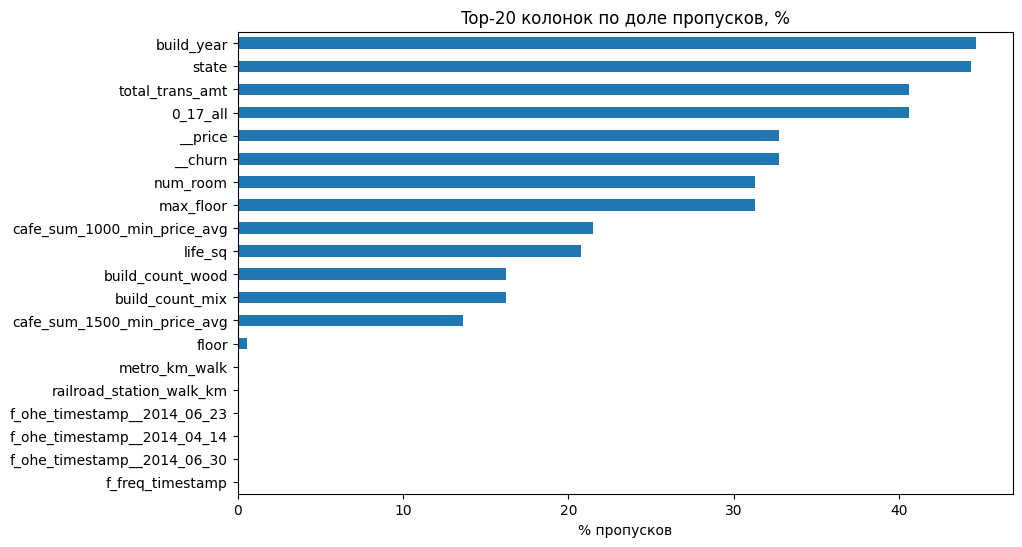

In [11]:
display(dataset.info())
display(dataset.describe(include="all").T.head(20))

# Пропуски
na_cnt = dataset.isna().sum().sort_values(ascending=False)
na_pct = (na_cnt / len(dataset) * 100).round(2)
na_table = pd.DataFrame({"na_cnt": na_cnt, "na_pct": na_pct})
display(na_table.head(20))

# Визуализация пропусков
plt.figure(figsize=(10, 6))
na_table.head(20)["na_pct"][::-1].plot(kind="barh")
plt.title("Top-20 колонок по доле пропусков, %")
plt.xlabel("% пропусков")
plt.show()


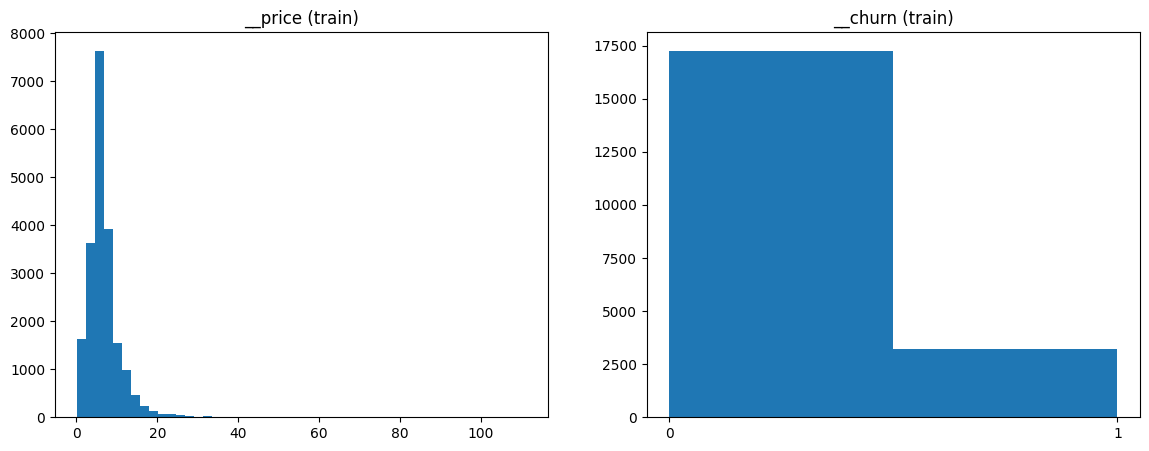

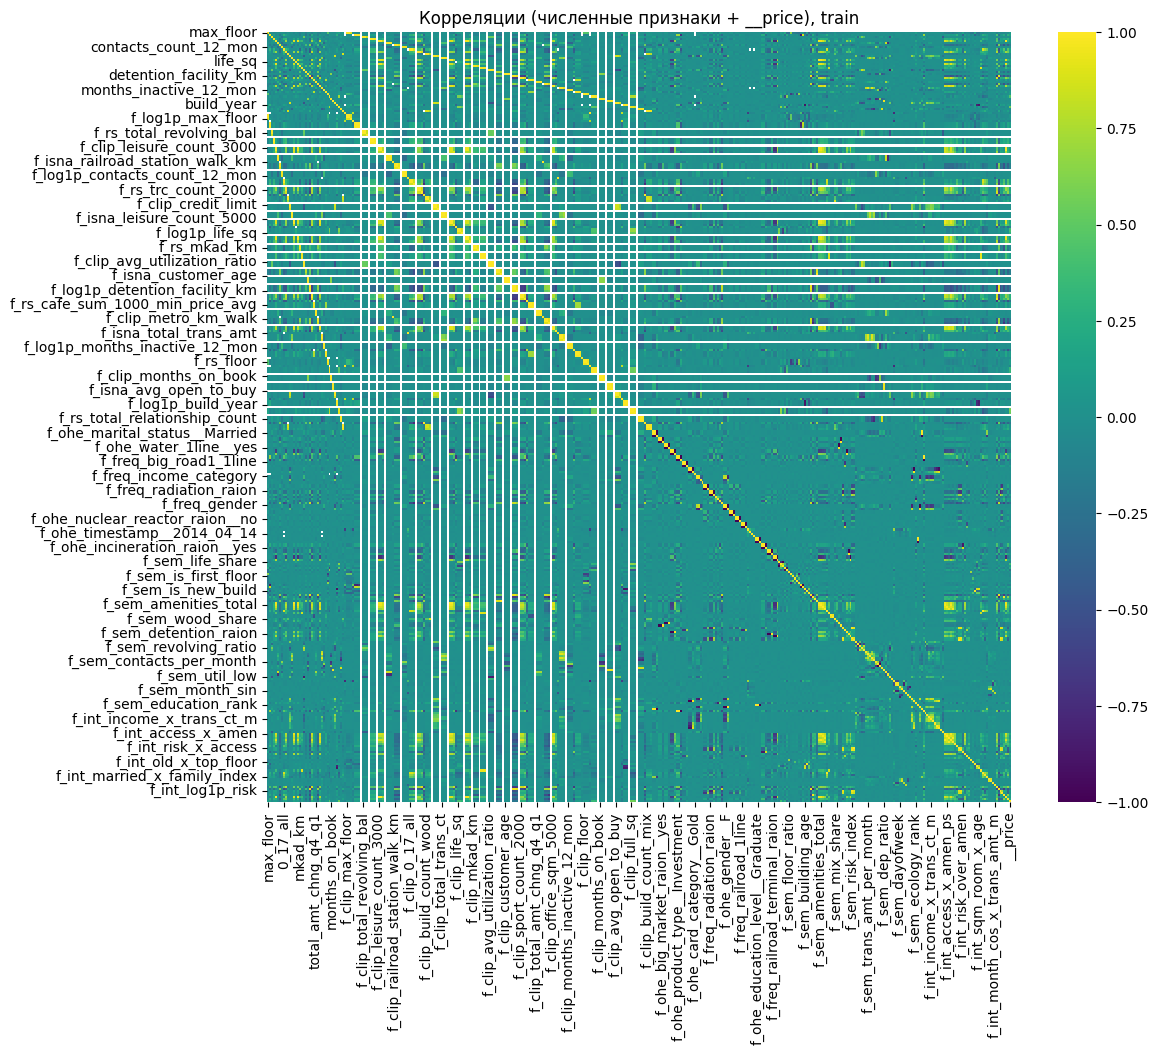

In [14]:
# Цели  на train_all
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(train_all["__price"], bins=50)
ax[0].set_title("__price (train)")

ax[1].hist(train_all["__churn"], bins=2)
ax[1].set_xticks([0, 1])
ax[1].set_title("__churn (train)")

plt.show()

# Корреляции для численных признаков
num_cols = dataset.select_dtypes(include=["int64", "float64"]).columns.tolist()
for t in ["__price", "__churn"]:
    if t in num_cols:
        num_cols.remove(t)

corr = train_all[num_cols + ["__price"]].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="viridis", center=0)
plt.title("Корреляции (численные признаки + __price), train")
plt.show()


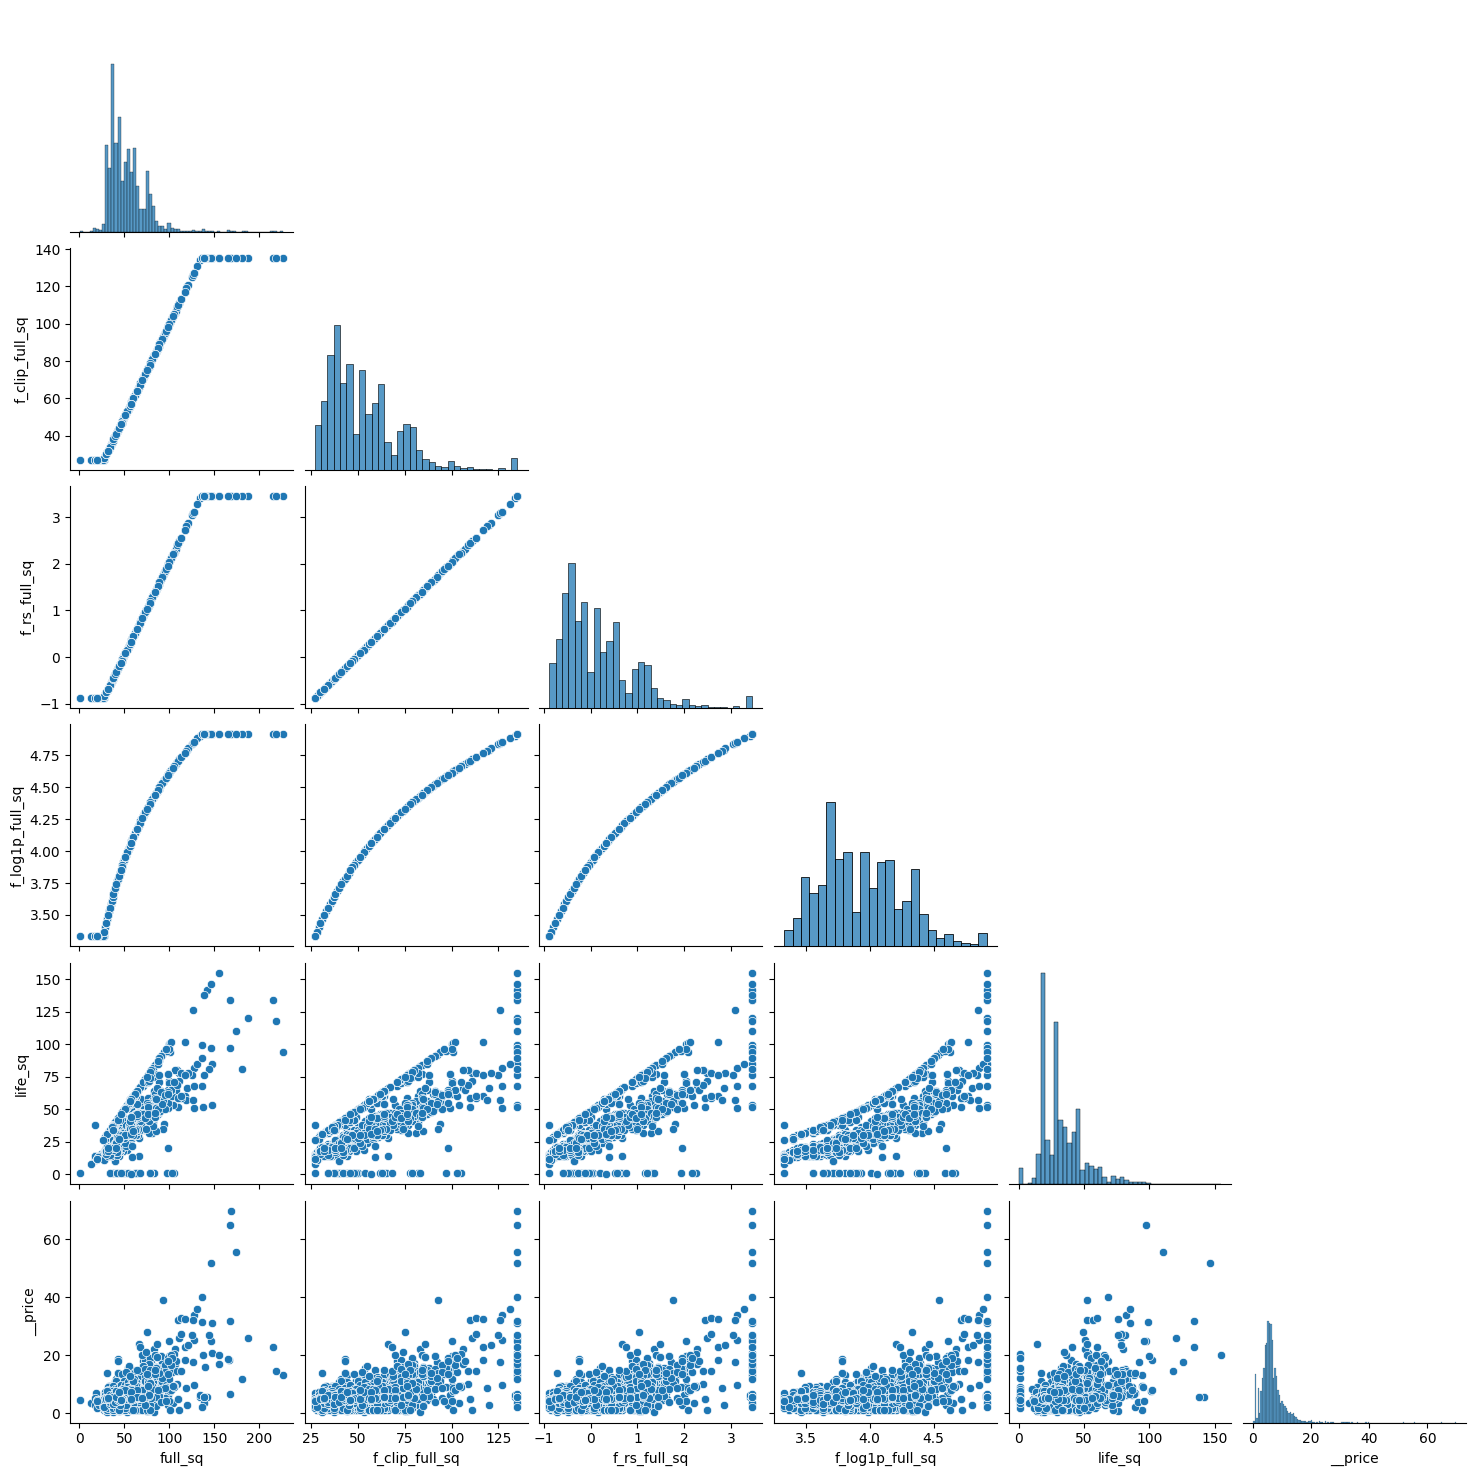

In [15]:
# Pairplot
# 1) берём случайную подвыборку строк
# 2) берём несколько численных признаков по корреляции с __price

sample = train_all.sample(n=min(3000, len(train_all)), random_state=42)

corr_to_price = sample[num_cols + ["__price"]].corr(numeric_only=True)["__price"].abs().sort_values(ascending=False)
top_features = [c for c in corr_to_price.index if c != "__price"][:5]

sns.pairplot(sample, vars=top_features + ["__price"], corner=True)
plt.show()


In [16]:
def add_datetime_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "timestamp" in df.columns:
        ts = pd.to_datetime(df["timestamp"], errors="coerce")
        df["timestamp_year"] = ts.dt.year
        df["timestamp_month"] = ts.dt.month
        df["timestamp_dayofweek"] = ts.dt.dayofweek
        df = df.drop(columns=["timestamp"])
    return df

# Применяем ко всему dataset
dataset = add_datetime_features(dataset)
train_all = add_datetime_features(train_all)
test_public = add_datetime_features(test_public)

print("timestamp in columns?", "timestamp" in dataset.columns)


timestamp in columns? False


In [17]:
TARGET_PRICE = "__price"
TARGET_CHURN = "__churn"

DROP_COLS = ["dtype", TARGET_PRICE, TARGET_CHURN]
DROP_COLS = [c for c in DROP_COLS if c in dataset.columns]

X_all = dataset.drop(columns=DROP_COLS)
X_train_all = train_all.drop(columns=DROP_COLS)

y_price_all = train_all[TARGET_PRICE].astype(float)
y_churn_all = train_all[TARGET_CHURN].astype(int)

print("X_all shape:", X_all.shape)
print("X_train_all shape:", X_train_all.shape)


X_all shape: (30471, 398)
X_train_all shape: (20483, 398)


In [18]:
# Сначала отделяем holdout 20%
idx = train_all.index

idx_train_fit, idx_tmp = train_test_split(
    idx,
    test_size=0.4,
    random_state=42,
    stratify=y_churn_all,  # стратифицируем по churn
)

# tmp делим на valid 20% и holdout 20%
y_tmp = y_churn_all.loc[idx_tmp]
idx_valid, idx_holdout = train_test_split(
    idx_tmp,
    test_size=0.5,
    random_state=42,
    stratify=y_tmp,
)

X_train_fit = X_train_all.loc[idx_train_fit]
X_valid = X_train_all.loc[idx_valid]
X_holdout = X_train_all.loc[idx_holdout]

y_price_train = y_price_all.loc[idx_train_fit]
y_price_valid = y_price_all.loc[idx_valid]
y_price_holdout = y_price_all.loc[idx_holdout]

y_churn_train = y_churn_all.loc[idx_train_fit]
y_churn_valid = y_churn_all.loc[idx_valid]
y_churn_holdout = y_churn_all.loc[idx_holdout]

print("Split sizes:")
print("train_fit:", X_train_fit.shape, y_churn_train.mean())
print("valid:", X_valid.shape, y_churn_valid.mean())
print("holdout:", X_holdout.shape, y_churn_holdout.mean())


Split sizes:
train_fit: (12289, 398) 0.15705102123850598
valid: (4097, 398) 0.15718818647791066
holdout: (4097, 398) 0.15694410544300708


In [19]:
# Определяем численные и категориальные признаки по dtype
num_features = X_train_fit.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train_fit.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("num_features:", len(num_features))
print("cat_features:", len(cat_features))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ],
    remainder="drop",
)


num_features: 376
cat_features: 19


In [20]:

def metric_for_price(y_true, y_pred):
    """
    mean_squared_log_error bigger is better
    Реализуем как -MSLE
    """
    y_pred = np.maximum(y_pred, 0)  # защитка
    return round(-mean_squared_log_error(y_true=y_true, y_pred=y_pred), 3)

def metric_for_churn(y_true, y_score):
    """ roc_auc_score. bigger is better """
    return round(roc_auc_score(y_true=y_true, y_score=y_score), 3)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "r2": r2_score(y_true, y_pred),
    }


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
from tqdm.auto import tqdm

# Таблица
scoring_price = pd.DataFrame([], columns=["model", "alpha", "metric_name", "score_train", "score_valid"])

# Расширенная таблица,
scoring_price_ext = []

def run_reg_experiment(model_name, model, alpha_value):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train_fit, y_price_train)

    pred_train = pipe.predict(X_train_fit)
    pred_valid = pipe.predict(X_valid)

    s_train = metric_for_price(y_price_train, pred_train)
    s_valid = metric_for_price(y_price_valid, pred_valid)

    # В таблицу H2
    row_h2 = {
        "model": model_name,
        "alpha": alpha_value,
        "metric_name": "mean_squared_log_error",
        "score_train": s_train,
        "score_valid": s_valid,
    }

    # В расширенную таблицу
    metr_train = regression_metrics(y_price_train, pred_train)
    metr_valid = regression_metrics(y_price_valid, pred_valid)

    row_ext = {
        "model": model_name,
        "alpha": alpha_value,
        "H2_score_train": s_train,
        "H2_score_valid": s_valid,
        **{f"train_{k}": v for k, v in metr_train.items()},
        **{f"valid_{k}": v for k, v in metr_valid.items()},
    }

    return row_h2, row_ext, pipe

# Сетки alpha
ALPHAS = np.logspace(-4, 2, 12)  # 12 экспериментов

models_reg = []

# Baseline: LinearRegression
models_reg.append(("LinearRegression", 0.0, LinearRegression()))

# Lasso: alpha grid
for a in ALPHAS:
    models_reg.append(("Lasso", float(a), Lasso(alpha=float(a), max_iter=10000, random_state=42)))

# Ridge: alpha grid
for a in ALPHAS:
    models_reg.append(("Ridge", float(a), Ridge(alpha=float(a), random_state=42)))

best_reg = {"model": None, "alpha": None, "score_valid": -np.inf, "pipe": None}

for (mname, aval, model) in tqdm(models_reg, desc="Regression experiments"):
    row_h2, row_ext, pipe = run_reg_experiment(mname, model, aval)
    scoring_price = pd.concat([scoring_price, pd.DataFrame([row_h2])], ignore_index=True)
    scoring_price_ext.append(row_ext)

    if row_h2["score_valid"] > best_reg["score_valid"]:
        best_reg = {"model": mname, "alpha": aval, "score_valid": row_h2["score_valid"], "pipe": pipe}

scoring_price_ext = pd.DataFrame(scoring_price_ext)

display(scoring_price.sort_values("score_valid", ascending=False).head(15))
print("Best regression:", best_reg)


Regression experiments:   0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_338/1914673643.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scoring_price = pd.concat([scoring_price, pd.DataFrame([row_h2])], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.906e+04, tolerance: 2.574e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or conside

,model,alpha,metric_name,score_train,score_valid
1,Lasso,0.000100,mean_squared_log_error,-0.152,-0.147
3,Lasso,0.001233,mean_squared_log_error,-0.151,-0.147
2,Lasso,0.000351,mean_squared_log_error,-0.152,-0.147
4,Lasso,0.004329,mean_squared_log_error,-0.152,-0.147
20,Ridge,0.657933,mean_squared_log_error,-0.152,-0.147
13,Ridge,0.000100,mean_squared_log_error,-0.152,-0.147
14,Ridge,0.000351,mean_squared_log_error,-0.152,-0.147
15,Ridge,0.001233,mean_squared_log_error,-0.152,-0.147
16,Ridge,0.004329,mean_squared_log_error,-0.152,-0.147
21,Ridge,2.310130,mean_squared_log_error,-0.152,-0.147


Best regression: {'model': 'Lasso', 'alpha': 0.0001, 'score_valid': -0.147, 'pipe': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['max_floor', 'state',
                                                   'total_revolving_bal',
                                                   'market_count_1500',
                                                   'leisure_count_3000',
                                                   'total_ct_chng_q4_q1',
                                                   'railroad_station_walk_km',
                                    

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def classification_metrics(y_true, prob_pred, thr=0.5):
    y_hat = (prob_pred >= thr).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, prob_pred),
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
    }

In [24]:
# Таблица
scoring_churn = pd.DataFrame([], columns=["model", "C", "metric_name", "score_train", "score_valid"])

# Расширенная таблица
scoring_churn_ext = []

def build_logreg(penalty, C=None, solver=None):
    """
     без регуляризации = penalty=None
    """
    if penalty is None:
        return LogisticRegression(
            penalty=None,
            solver=solver or "lbfgs",
            max_iter=2000,
        )
    else:
        return LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=3000,
        )

def run_clf_experiment(model_name, clf, C_value):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf),
    ])
    pipe.fit(X_train_fit, y_churn_train)

    prob_train = pipe.predict_proba(X_train_fit)[:, 1]
    prob_valid = pipe.predict_proba(X_valid)[:, 1]

    s_train = metric_for_churn(y_churn_train, prob_train)
    s_valid = metric_for_churn(y_churn_valid, prob_valid)

    row_h2 = {
        "model": model_name,
        "C": C_value,
        "metric_name": "roc_auc_score",
        "score_train": s_train,
        "score_valid": s_valid,
    }

    metr_train = classification_metrics(y_churn_train, prob_train)
    metr_valid = classification_metrics(y_churn_valid, prob_valid)

    row_ext = {
        "model": model_name,
        "C": C_value,
        "H2_score_train": s_train,
        "H2_score_valid": s_valid,
        **{f"train_{k}": v for k, v in metr_train.items()},
        **{f"valid_{k}": v for k, v in metr_valid.items()},
    }

    return row_h2, row_ext, pipe


# Сетка
C_GRID = np.logspace(-3, 3, 12)

models_clf = []

# Без регуляризации
models_clf.append(("LogReg_none", np.nan, build_logreg(penalty=None, solver="lbfgs")))

# L1: liblinear
for C in C_GRID:
    models_clf.append(("LogReg_L1", float(C), build_logreg(penalty="l1", C=float(C), solver="liblinear")))

# L2: lbfgs
for C in C_GRID:
    models_clf.append(("LogReg_L2", float(C), build_logreg(penalty="l2", C=float(C), solver="lbfgs")))

best_clf = {"model": None, "C": None, "score_valid": -np.inf, "pipe": None}

for (mname, cval, clf) in tqdm(models_clf, desc="Classification experiments"):
    row_h2, row_ext, pipe = run_clf_experiment(mname, clf, cval)
    scoring_churn = pd.concat([scoring_churn, pd.DataFrame([row_h2])], ignore_index=True)
    scoring_churn_ext.append(row_ext)

    if row_h2["score_valid"] > best_clf["score_valid"]:
        best_clf = {"model": mname, "C": cval, "score_valid": row_h2["score_valid"], "pipe": pipe}

scoring_churn_ext = pd.DataFrame(scoring_churn_ext)

display(scoring_churn.sort_values("score_valid", ascending=False).head(15))
print("Best classification:", best_clf)

Classification experiments:   0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_338/1272517983.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scoring_churn = pd.concat([scoring_churn, pd.DataFrame([row_h2])], ignore_index=True)
/tmp/ipykernel_338/1272517983.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scoring_churn = pd.concat([scoring_churn, pd.DataFrame([row_h2])], ignore_index=True)


,model,C,metric_name,score_train,score_valid
6,LogReg_L1,0.533670,roc_auc_score,0.974,0.971
5,LogReg_L1,0.151991,roc_auc_score,0.972,0.971
0,LogReg_none,NaN,roc_auc_score,0.975,0.969
4,LogReg_L1,0.043288,roc_auc_score,0.969,0.969
7,LogReg_L1,1.873817,roc_auc_score,0.975,0.969
8,LogReg_L1,6.579332,roc_auc_score,0.975,0.969
11,LogReg_L1,284.803587,roc_auc_score,0.975,0.969
10,LogReg_L1,81.113083,roc_auc_score,0.975,0.969
9,LogReg_L1,23.101297,roc_auc_score,0.975,0.969
21,LogReg_L2,23.101297,roc_auc_score,0.975,0.969


Best classification: {'model': 'LogReg_L1', 'C': 0.1519911082952933, 'score_valid': np.float64(0.971), 'pipe': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['max_floor', 'state',
                                                   'total_revolving_bal',
                                                   'market_count_1500',
                                                   'leisure_count_3000',
                                                   'total_ct_chng_q4_q1',
                                                   'railroad_station_walk_km',
         

In [25]:
# Регрессия best_reg["pipe"] обучена на train_fit
reg_pipe = best_reg["pipe"]
pred_holdout = reg_pipe.predict(X_holdout)
print("Regression holdout metrics:", regression_metrics(y_price_holdout, pred_holdout))

# Классификация best_clf["pipe"] обучена на train_fit
clf_pipe = best_clf["pipe"]
prob_holdout = clf_pipe.predict_proba(X_holdout)[:, 1]
print("Classification holdout metrics:", classification_metrics(y_churn_holdout, prob_holdout))


Regression holdout metrics: {'mae': 1.7364830852171624, 'mse': 8.235061451521537, 'rmse': np.float64(2.869679677511331), 'r2': 0.5597406174398125}
Classification holdout metrics: {'roc_auc': np.float64(0.9649258281020225), 'accuracy': 0.9262875274591165, 'precision': 0.7781402936378466, 'recall': 0.7418351477449455}


In [26]:
# Переобучаем лучшие пайплайны
best_reg_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_reg["pipe"].named_steps["model"]),
])

best_clf_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_clf["pipe"].named_steps["model"]),
])

best_reg_final.fit(X_train_all, y_price_all)
best_clf_final.fit(X_train_all, y_churn_all)

# Предсказываем
pred_price_all = best_reg_final.predict(X_all)
pred_price_all = np.maximum(pred_price_all, 0)

prob_churn_all = best_clf_final.predict_proba(X_all)[:, 1]

dataset["__price_predict"] = pred_price_all
dataset["__churn_prob"] = prob_churn_all

dataset[["__price_predict", "__churn_prob"]].head()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.149e+04, tolerance: 4.310e+01
  model = cd_fast.enet_coordinate_descent(


,__price_predict,__churn_prob
0,3.895704,0.000251
1,7.989289,0.050737
2,1.854151,0.349202
3,3.218442,0.020001
4,3.036367,0.002548


In [27]:
# Какие столбцы не являются признаками
drop_cols = {"dtype", "__price", "__churn", "__price_predict", "__churn_prob", "__priority"}

feature_cols = [c for c in dataset.columns if c not in drop_cols]
print("n_features:", len(feature_cols))
print("first features:", feature_cols[:20])

n_features: 398
first features: ['max_floor', 'state', 'marital_status', 'big_market_raion', 'total_revolving_bal', 'market_count_1500', 'leisure_count_3000', 'total_ct_chng_q4_q1', 'water_1line', 'railroad_station_walk_km', 'culture_objects_top_25', 'contacts_count_12_mon', '0_17_all', 'trc_count_2000', 'product_type', 'build_count_wood', 'credit_limit', 'total_trans_ct', 'leisure_count_5000', 'life_sq']


In [28]:
# Обновим train_all
train_all = dataset[dataset["dtype"] == "train"].copy()

X_all = train_all[feature_cols]
y_price_all = train_all["__price"]
y_churn_all = train_all["__churn"]

best_reg_pipe = best_reg["pipe"]
best_clf_pipe = best_clf["pipe"]

best_reg_pipe.fit(X_all, y_price_all)
best_clf_pipe.fit(X_all, y_churn_all)

print("refit done")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.149e+04, tolerance: 4.310e+01
  model = cd_fast.enet_coordinate_descent(


refit done


In [29]:
X_full = dataset[feature_cols]

# Регрессия
price_pred = best_reg_pipe.predict(X_full)
price_pred = np.clip(price_pred, 0, None)

dataset["__price_predict"] = price_pred

# Классификация вероятность класса 1
dataset["__churn_prob"] = best_clf_pipe.predict_proba(X_full)[:, 1]

dataset[["__price_predict", "__churn_prob"]].head()

,__price_predict,__churn_prob
0,3.895704,0.000251
1,7.989289,0.050780
2,1.854151,0.349371
3,3.218442,0.019992
4,3.036367,0.002553


In [30]:
print(dataset[["__price_predict", "__churn_prob"]].isna().sum())
print(dataset[["__price_predict", "__churn_prob"]].describe())

__price_predict    0
__churn_prob       0
dtype: int64
       __price_predict  __churn_prob
count     30471.000000  3.047100e+04
mean          7.274521  1.565752e-01
std           3.591909  2.860581e-01
min           0.000000  5.646707e-09
25%           5.049946  2.980638e-04
50%           6.443934  5.169477e-03
75%           8.495859  1.348538e-01
max          38.448136  9.998481e-01


In [31]:
train_all = dataset[dataset["dtype"] == "train"].copy()
test = dataset[dataset["dtype"] == "test"].copy()

print(train_all.shape, test.shape)
print("__churn_prob" in train_all.columns, "__price_predict" in train_all.columns)

(20483, 403) (9988, 403)
True True


## Финальная проверка

In [32]:
# final metric check
score_churn = metric_for_churn(train_all['__churn'], train_all['__churn_prob'])
score_price = metric_for_price(train_all['__price'], train_all['__price_predict'])

score_churn, score_price

(np.float64(0.972), -0.151)

In [33]:

def alg1(x):
    """
    Algorithm version 1
    """
    return x['__price_predict']

# column __price_predict must be in dataset
dataset['__priority'] = dataset.apply(alg1, axis=1)

# ВАША РАБОТА ЗАКОНЧЕНА (Создание файла для сдачи)

In [34]:
# this columns in dataset
prediction_columns = ['__price_predict', '__churn_prob', '__priority']

SHAPE = dataset.shape

submission = dataset[prediction_columns]

if submission.isnull().sum().sum() > 0:
    raise ValueError("Submission dataset contained NaN values")

if submission.shape[0] != SHAPE[0]:
    raise ValueError(f'Incorrect submission file shape. Original {SHAPE[0]}. {submission.shape[0]} are given')

output_path = f'2_{NAME}.csv'
print(f"output file '{output_path}' was created")

submission.to_csv(output_path, index=True)

output file '2_Kirill_Viksman.csv' was created


In [35]:
import pandas as pd

submission = pd.read_csv("2_Kirill_Viksman.csv", index_col=0)
submission.head()

,__price_predict,__churn_prob,__priority
0,3.895704,0.000251,3.895704
1,7.989289,0.050780,7.989289
2,1.854151,0.349371,1.854151
3,3.218442,0.019992,3.218442
4,3.036367,0.002553,3.036367


In [37]:
print(submission.shape)
print(submission.columns.tolist())
submission.head(10)

(30471, 3)
['__price_predict', '__churn_prob', '__priority']


,__price_predict,__churn_prob,__priority
0,3.895704,0.000251,3.895704
1,7.989289,0.050780,7.989289
2,1.854151,0.349371,1.854151
3,3.218442,0.019992,3.218442
4,3.036367,0.002553,3.036367
5,3.575891,0.000620,3.575891
6,8.585376,0.065788,8.585376
7,12.427849,0.016263,12.427849
8,6.930089,0.559190,6.930089
9,9.993968,0.000006,9.993968
